In [89]:
from scipy.signal import butter, sosfilt, sosfilt_zi
import numpy as np
from matplotlib import pyplot as plt
from scipy.fft import fft as scipy_fft
import os

In [2]:
myfilt = butter(10,Wn=0.1,fs=1,output='sos',btype='lowpass')

In [22]:
x = np.zeros(100)
x[0]=1


In [23]:
filt_x = sosfilt(myfilt,x)


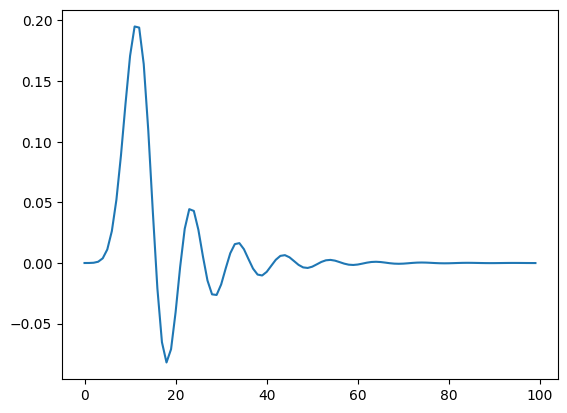

In [24]:
plt.plot(filt_x)

/tmp/ipykernel_1750147/1473013354.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(freqs,10*np.log10(ps/ps.max()))


(0.0, 0.2)

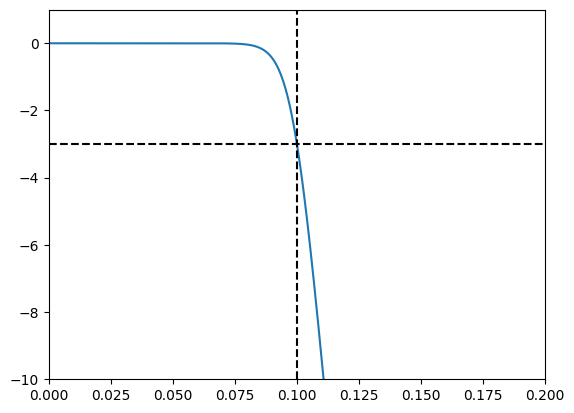

In [95]:
freqs = np.arange(len(x)//2+1)/len(x)
ps = np.abs(np.fft.rfft(filt_x))**2
plt.plot(freqs,10*np.log10(ps/ps.max()))
plt.axvline(0.1,ls='--',c='black')
plt.axhline(-3,ls='--',c='black')
plt.ylim(-10,1)
plt.xlim(0,0.2)

In [48]:
nn=2000
x1 = np.random.randn(nn)
x2 = np.random.randn(nn)
x3 = np.hstack([x1,x2])

In [74]:
zi = sosfilt_zi(myfilt)

In [61]:
filt_x1, zf = sosfilt(myfilt, x1, zi=zi)
filt_x2, zf2 = sosfilt(myfilt, x2, zi=zf)

In [62]:
filt_x3, zf3 = sosfilt(myfilt, x3, zi=zi)

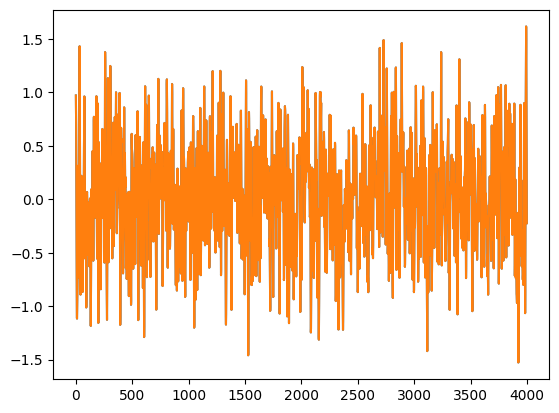

In [63]:
concat_filt_x = np.hstack([filt_x1, filt_x2])
plt.plot(concat_filt_x)
plt.plot(filt_x3)

In [65]:
np.sum(concat_filt_x-filt_x3)

np.float64(0.0)

In [ ]:
#discontinuity at the boundary if filter values not propagated correctly

In [59]:
filt_x1, zf = sosfilt(myfilt, x1, zi=zi)
filt_x2, zf2 = sosfilt(myfilt, x2, zi=zi)

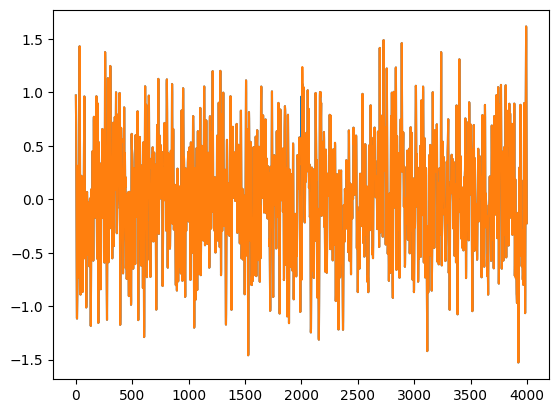

In [60]:
concat_filt_x = np.hstack([filt_x1, filt_x2])
plt.plot(concat_filt_x)
plt.plot(filt_x3)

FIR filtering of a long timestream

In [62]:
nn=200000
x1 = np.random.randn(nn)

x1 = x1.reshape(-1,2000)
print(x1.shape)

(100, 2000)


In [79]:
x1_filt_scipy, _ = sosfilt(myfilt,np.ravel(x1),zi=zi)

In [64]:
crap_len = len(filt_x)

In [48]:
hf = np.fft.rfft(np.hstack([filt_x, np.zeros(x1.shape[1]-crap_len)]))
print(len(hf))

1001


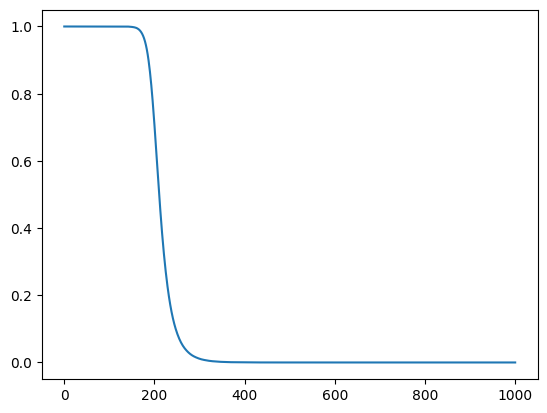

In [30]:
plt.plot(np.abs(hf))

In [65]:
x1f = np.fft.rfft(x1,axis=1)

In [66]:
x1_filt = np.fft.irfft(x1f * hf[None,:])

In [67]:
x1_filt_orig=x1_filt.copy()

In [68]:
temp = np.zeros(2*crap_len)
small_hf = temp.copy()
small_hf[:crap_len] = filt_x
small_hf = np.fft.rfft(small_hf)
print(small_hf.shape)
for i in range(1,x1.shape[0]):
    temp[:crap_len] = x1[i-1,-crap_len:]
    temp[crap_len:2*crap_len] = x1[i,:crap_len]
    x1_filt[i, :crap_len] = np.fft.irfft(np.fft.rfft(temp)*small_hf)[crap_len:2*crap_len]
    

(101,)


In [69]:
x1_filt[1,crap_len]

np.float64(0.06870060080719151)

In [70]:
x1_filt_orig[1,crap_len]

np.float64(0.06870060080719151)

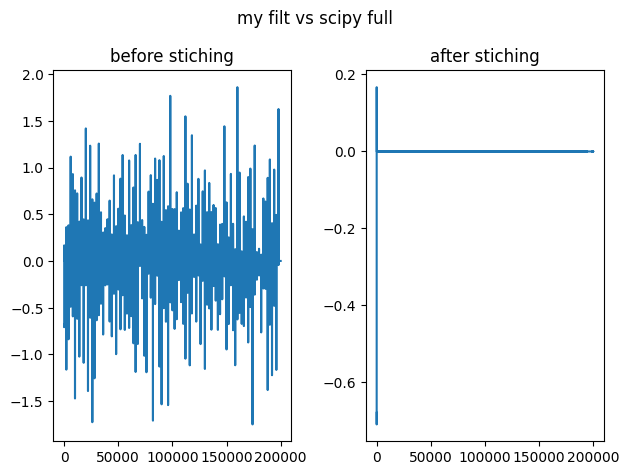

In [86]:
plt.suptitle("my filt vs scipy full")
plt.subplot(121)
plt.title("before stiching")
plt.plot(np.ravel(x1_filt_orig)-x1_filt_scipy)

plt.subplot(122)
plt.title("after stiching")
plt.plot(np.ravel(x1_filt)-x1_filt_scipy)
plt.tight_layout()